# Подготовка датасета DFEW

Создается `DataLoader` для побатчевой подаче данный для обучения.
``` python
X: 8 frames
y: 1 label (1-7)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [24]:
class DFEWDataset(Dataset):
    def __init__(self, frame_paths, annots_df, n_frames=8, transform=None):
        self.transform = transform or transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

        self.label_map = dict(zip(annots_df['order'], annots_df['label']))

        self.samples = []
        for path in frame_paths:
            order = int(os.path.basename(path))
            if order in self.label_map:
                self.samples.append((path, self.label_map[order]))

        self.n_frames = n_frames

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        clip_path, label = self.samples[idx]
        label_tensor = torch.tensor(label, dtype=torch.long)

        frames = self._load_frames(clip_path)
        return frames, label_tensor

    def _load_frames(self, clip_path):
        files = sorted(os.listdir(clip_path))
        indices = np.linspace(0, len(files) - 1, self.n_frames, dtype=int)

        frames = []
        for i in indices:
            img = cv2.imread(os.path.join(clip_path, files[i]))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            frames.append(self.transform(img))

        return torch.stack(frames)

In [38]:
base_path = r"D:\Datasets\DFEW\clips"
annot_path = r"D:\Datasets\DFEW\annotation\annotation.xlsx"

frame_paths = []
annots = pd.read_excel(annot_path)

for part_dir in os.listdir(base_path):
    part_path = os.path.join(base_path, part_dir, part_dir)  # e.g. clips/clip_224x224_part_1/clip_224x224_part_1
    if not os.path.isdir(part_path):
        continue
    
    for frame in os.listdir(part_path):
        frame_full_path = os.path.join(part_path, frame)
        if not os.path.isdir(frame_full_path):
            continue
        
        n_files = len(os.listdir(frame_full_path))
        if 7 < n_files <= 50:
            frame_paths.append(frame_full_path)

print(f"Total clips found: {len(frame_paths)}")

Total clips found: 577


In [39]:
# 1. Создаём датасет
dataset = DFEWDataset(frame_paths, annots)
print(f"Всего клипов: {len(dataset)}")

# 2. Один элемент вручную
frames, label = dataset[0]
print(f"Frames shape: {frames.shape}")
print(f"Label: {label}")

# 3. Проверяем DataLoader — один батч
dataloader = DataLoader(dataset, batch_size=4, shuffle=False, num_workers=0)
frames_batch, labels_batch = next(iter(dataloader))
print(f"Batch frames: {frames_batch.shape}")
print(f"Batch labels: {labels_batch.shape}")
print(f"Labels в батче: {labels_batch}")

# 4. Проверяем что аннотации совпадают
path, expected_label = dataset.samples[0]
order = int(os.path.basename(path))
print(f"Путь: {path}")
print(f"Order: {order}, Label из датасета: {expected_label}, Label из annots: {annots[annots['order'] == order]['label'].values}")

Всего клипов: 577
Frames shape: torch.Size([8, 3, 224, 224])
Label: 2
Batch frames: torch.Size([4, 8, 3, 224, 224])
Batch labels: torch.Size([4])
Labels в батче: tensor([2, 4, 2, 5])
Путь: D:\Datasets\DFEW\clips\clip_224x224_part_1\clip_224x224_part_1\00004
Order: 4, Label из датасета: 2, Label из annots: [2]


In [40]:
def test_dataset_visual(dataset, idx=0):
    frames, labels = dataset[idx]
    path, _ = dataset.samples[idx]
    order = int(os.path.basename(path))

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    fig, axes = plt.subplots(1, dataset.n_frames, figsize=(20, 3))
    fig.suptitle(f"order={order} | label={labels.item()}", fontsize=13)

    for col in range(dataset.n_frames):
        img = frames[col] * std + mean
        img = img.permute(1, 2, 0).clip(0, 1).numpy()

        axes[col].imshow(img)
        axes[col].set_title(f"Кадр {col+1}")
        axes[col].axis("off")

    plt.tight_layout()
    plt.show()

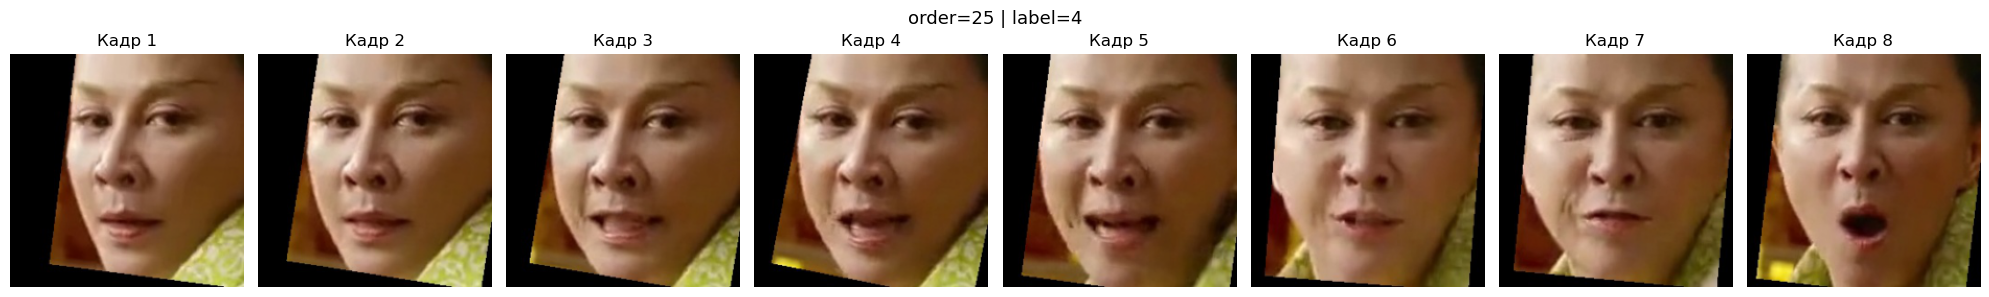

In [41]:
dataset_nn  = DFEWDataset(frame_paths, annots)
test_dataset_visual(dataset_nn,  idx=10)
